# Portfolio Optimization: Monte Carlo

**451 - Coding Assignment 2**

**Author:** Michael Dawson


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

SAMPLE_SIZE = 700      # number of asset return scenarios to generate
N_PORTFOLIOS = 700     # number of random portfolios to try
SEED_RETURNS = 1111    # matches the R jump-start
SEED_WEIGHTS = 9999    # matches the R jump-start

In [27]:
def make_random_weights(n_assets, allow_shorts):
    """One random weight vector that sums to 1."""
    if allow_shorts:
        # Draw n-1 weights uniformly between -1 and 1; last weight makes them sum to 1
        first_weights = np.random.uniform(-1, 1, size=n_assets - 1)
        last_weight = 1.0 - first_weights.sum()
        return np.append(first_weights, last_weight)
    else:
        # Draw n weights between 0 and 1, then normalize so they sum to 1
        weights = np.random.uniform(0, 1, size=n_assets)
        return weights / weights.sum()

def build_opportunity_set(returns_data, cov_matrix, n_portfolios, allow_shorts):
    """Try N random portfolios and record each one's risk and return."""
    n_assets = returns_data.shape[1]
    results = []
    for i in range(n_portfolios):
        weights = make_random_weights(n_assets, allow_shorts)
        portfolio_returns = returns_data @ weights
        mean_return = portfolio_returns.mean()
        risk = np.sqrt(weights @ cov_matrix @ weights)
        has_short = (weights < 0).any()
        results.append({'ret_mean': mean_return, 'ret_sd': risk, 'has_short': has_short})
    return pd.DataFrame(results)

def optimize_portfolio(mu, cov, risk_aversion, allow_shorts):
    """Find the optimal weights by maximizing return - (risk_aversion/2)*variance."""
    n_assets = len(mu)
    
    def objective(w):
        # Negate because scipy minimizes but we want to maximize
        return -(w @ mu - 0.5 * risk_aversion * (w @ cov @ w))
    
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}]
    bounds = None if allow_shorts else [(0, 1)] * n_assets
    initial_guess = np.ones(n_assets) / n_assets
    result = minimize(objective, initial_guess, method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x

def compute_efficient_frontier(mu, cov, allow_shorts, n_points=50):
    """Trace the efficient frontier by solving at many risk-aversion values."""
    risk_aversions = np.logspace(0, np.log10(200), n_points)
    results = []
    for ra in risk_aversions:
        weights = optimize_portfolio(mu, cov, ra, allow_shorts)
        results.append({
            'risk_aversion': ra,
            'ret_mean': weights @ mu,
            'ret_sd': np.sqrt(weights @ cov @ weights),
            **{f'w{j+1}': w for j, w in enumerate(weights)}
        })
    return pd.DataFrame(results)

In [28]:
asset_names_1 = ['A', 'B', 'C', 'D']
mu_1 = np.array([0.02, 0.07, 0.15, 0.20])
sd_1 = np.array([0.05, 0.12, 0.17, 0.25])
cor_1 = np.array([
    [1.0, 0.3, 0.3, 0.3],
    [0.3, 1.0, 0.6, 0.6],
    [0.3, 0.6, 1.0, 0.6],
    [0.3, 0.6, 0.6, 1.0],
])
cov_1 = np.outer(sd_1, sd_1) * cor_1   # build covariance matrix from sd and correlation

In [29]:
np.random.seed(SEED_RETURNS)
returns_1 = np.random.multivariate_normal(mean=mu_1, cov=cov_1, size=SAMPLE_SIZE)
returns_1_df = pd.DataFrame(returns_1, columns=asset_names_1)
returns_1_df.describe().round(4)

,A,B,C,D
count,700.0000,700.0000,700.0000,700.0000
mean,0.0197,0.0643,0.1520,0.1936
std,0.0479,0.1174,0.1743,0.2472
min,-0.1184,-0.2385,-0.5398,-0.6819
25%,-0.0131,-0.0137,0.0295,0.0337
50%,0.0204,0.0610,0.1526,0.1972
75%,0.0525,0.1413,0.2687,0.3587
max,0.1756,0.4412,0.6431,0.9008


In [30]:
sample_cov_1 = np.cov(returns_1, rowvar=False)

np.random.seed(SEED_WEIGHTS)
opp_short_1 = build_opportunity_set(returns_1, sample_cov_1, N_PORTFOLIOS, allow_shorts=True)

np.random.seed(SEED_WEIGHTS)
opp_long_1 = build_opportunity_set(returns_1, sample_cov_1, N_PORTFOLIOS, allow_shorts=False)

print(f"Shorts allowed: returns from {opp_short_1.ret_mean.min():.3f} to {opp_short_1.ret_mean.max():.3f}")
print(f"Long only:      returns from {opp_long_1.ret_mean.min():.3f} to {opp_long_1.ret_mean.max():.3f}")

Shorts allowed: returns from -0.122 to 0.492
Long only:      returns from 0.043 to 0.169


In [31]:
frontier_short_1 = compute_efficient_frontier(mu_1, cov_1, allow_shorts=True)
frontier_long_1 = compute_efficient_frontier(mu_1, cov_1, allow_shorts=False)
frontier_short_1.head()

,risk_aversion,ret_mean,ret_sd,w1,w2,w3,w4
0,1.000000,0.813672,0.894675,-3.412453,-1.472182,3.839057,2.045578
1,1.114191,0.732302,0.803689,-2.978189,-1.295640,3.444104,1.829725
2,1.241422,0.658296,0.720973,-2.583292,-1.135672,3.086681,1.632283
3,1.383182,0.592543,0.647521,-2.232337,-0.993538,2.768743,1.457131
4,1.541130,0.533551,0.581665,-1.918312,-0.863920,2.481104,1.301128


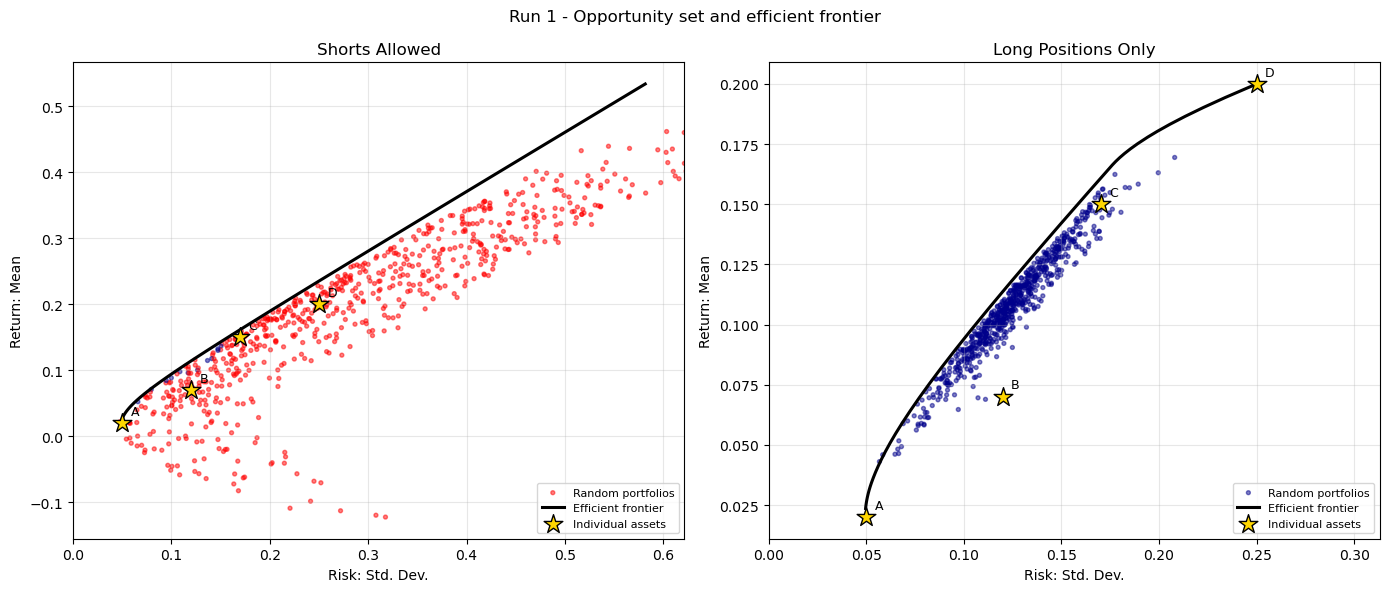

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Set sensible axis limits for each panel
sd_max_short = opp_short_1.ret_sd.quantile(0.98)
sd_max_long = max(opp_long_2.ret_sd.max(), sd_2.max()) * 1.10

for ax, opp_df, front_df, label, sd_max in [
    (axes[0], opp_short_1, frontier_short_1, 'Shorts Allowed', sd_max_short),
    (axes[1], opp_long_1, frontier_long_1, 'Long Positions Only', sd_max_long),
]:
    colors = ['red' if x else 'darkblue' for x in opp_df['has_short']]
    ax.scatter(opp_df['ret_sd'], opp_df['ret_mean'], c=colors, s=8, alpha=0.5, label='Random portfolios')
    visible = front_df[front_df['ret_sd'] <= sd_max]
    ax.plot(visible['ret_sd'], visible['ret_mean'], '-', color='black', lw=2.2, label='Efficient frontier')
    ax.scatter(sd_1, mu_1, marker='*', s=200, c='gold', edgecolors='black', zorder=5, label='Individual assets')
    for n, sd, m in zip(asset_names_1, sd_1, mu_1):
        ax.annotate(n, (sd, m), xytext=(6, 6), textcoords='offset points', fontsize=9)
    ax.set_xlim(0, sd_max)
    ax.set_xlabel('Risk: Std. Dev.')
    ax.set_ylabel('Return: Mean')
    ax.set_title(label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Run 1 - Opportunity set and efficient frontier')
fig.tight_layout()
fig.savefig('figures/run1_hypothetical_opportunity_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

*The efficient frontier traces the upper boundary of the random-portfolio cloud, confirming that optimization isolates the non-dominated portfolios. Allowing shorts (left) extends the frontier well beyond what long-only allows because the optimizer can short low-return asset A to lever into C and D.

### How do optimal weights shift as risk aversion changes?

The frontier table includes the optimal weights at each level of risk aversion. Plotting them shows how the optimizer trades off between assets as the investor becomes more or less risk-tolerant.

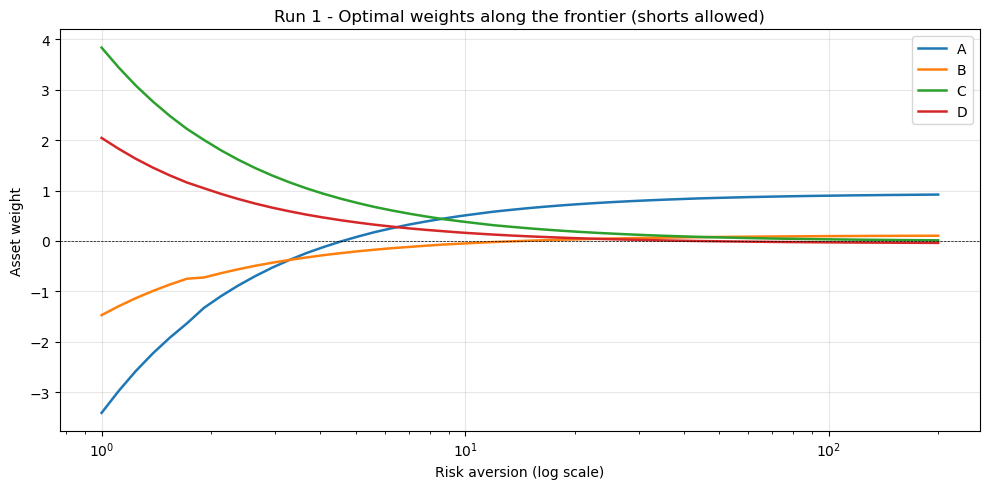

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
for j, name in enumerate(asset_names_1):
    ax.plot(frontier_short_1['risk_aversion'], frontier_short_1[f'w{j+1}'], label=name, lw=1.8)
ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_xlabel('Risk aversion (log scale)')
ax.set_ylabel('Asset weight')
ax.set_title('Run 1 - Optimal weights along the frontier (shorts allowed)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('figures/run1_hypothetical_weights_shorts.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading this plot.** At low risk aversion (left side) the optimizer takes aggressive positions: long the high-return assets C and D, short the low-return asset A to fund those longs. As risk aversion rises (right side), all weights collapse toward the global minimum-variance portfolio, dominated by the safe asset A.

### Stochastic programming via sample average approximation

Stochastic programming optimizes over realized scenarios instead of plugging in known $\mu$ and $\Sigma$. With our 700 simulated scenarios we use the **sample** mean and **sample** covariance from those scenarios to set up the optimization. With Gaussian scenarios this should give nearly the same answer as the deterministic optimum, with small differences due to sampling error.

In [34]:
lam = 5.0
sample_mu_1 = returns_1.mean(axis=0)

saa_weights = optimize_portfolio(sample_mu_1, sample_cov_1, lam, allow_shorts=True)
det_weights = optimize_portfolio(mu_1, cov_1, lam, allow_shorts=True)

pd.DataFrame({
    'Asset': asset_names_1,
    'SAA (sample-based)': np.round(saa_weights, 4),
    'Deterministic (population)': np.round(det_weights, 4),
})

,Asset,SAA (sample-based),Deterministic (population)
0,A,0.1566,0.0760
1,B,-0.2572,-0.2093
2,C,0.7523,0.7628
3,D,0.3482,0.3705


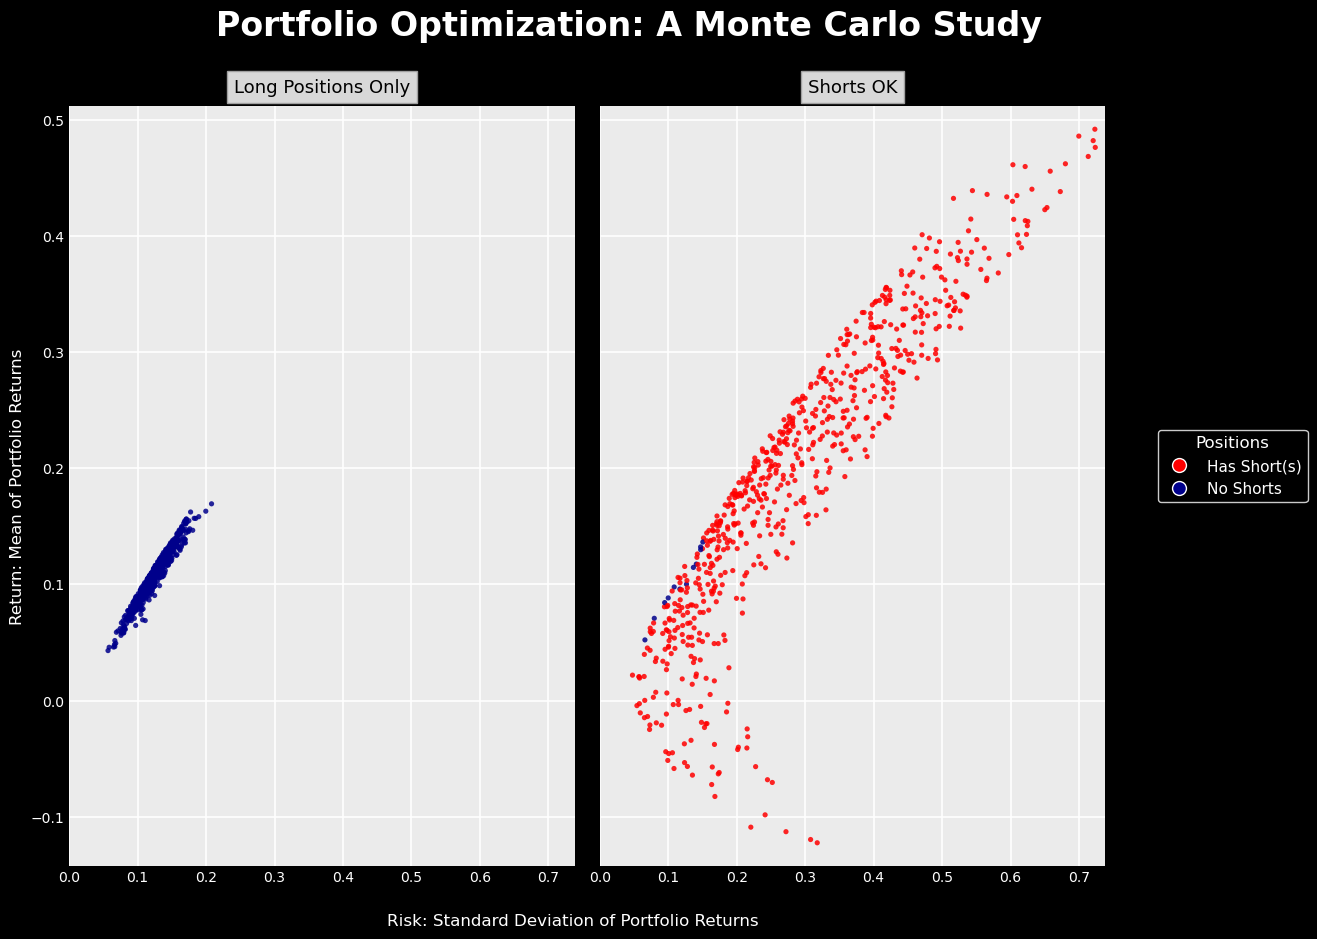

In [36]:


SAMPLE_SIZE = 700
N_PORTFOLIOS = 700
SEED_RETURNS = 1111
SEED_WEIGHTS = 9999

# Asset parameters (from the jump-start code)
mu = np.array([0.02, 0.07, 0.15, 0.20])
sd = np.array([0.05, 0.12, 0.17, 0.25])
correlation = np.array([
    [1.0, 0.3, 0.3, 0.3],
    [0.3, 1.0, 0.6, 0.6],
    [0.3, 0.6, 1.0, 0.6],
    [0.3, 0.6, 0.6, 1.0],
])

TITLE = "Portfolio Optimization: A Monte Carlo Study"



def make_random_weights(n_assets, allow_shorts):
    """One random weight vector that sums to 1."""
    if allow_shorts:
        first = np.random.uniform(-1, 1, size=n_assets - 1)
        return np.append(first, 1.0 - first.sum())
    w = np.random.uniform(0, 1, size=n_assets)
    return w / w.sum()


def opportunity_set(returns_data, sample_cov, n_portfolios, allow_shorts):
    """Try N random portfolios; record each one's risk and return."""
    rows = []
    n_assets = returns_data.shape[1]
    for _ in range(n_portfolios):
        w = make_random_weights(n_assets, allow_shorts)
        portfolio_returns = returns_data @ w
        rows.append({
            "ret_mean": portfolio_returns.mean(),
            "ret_sd": float(np.sqrt(w @ sample_cov @ w)),
            "has_short": bool((w < 0).any()),
        })
    return pd.DataFrame(rows)


cov = np.outer(sd, sd) * correlation

np.random.seed(SEED_RETURNS)
returns_data = np.random.multivariate_normal(mu, cov, size=SAMPLE_SIZE)
sample_cov = np.cov(returns_data, rowvar=False)

np.random.seed(SEED_WEIGHTS)
shorts_ok = opportunity_set(returns_data, sample_cov, N_PORTFOLIOS, allow_shorts=True)

np.random.seed(SEED_WEIGHTS)
long_only = opportunity_set(returns_data, sample_cov, N_PORTFOLIOS, allow_shorts=False)


# Common axis ranges so the two panels are directly comparable
sd_max = max(shorts_ok["ret_sd"].max(), long_only["ret_sd"].max()) * 1.02
ret_min = min(shorts_ok["ret_mean"].min(), long_only["ret_mean"].min()) - 0.02
ret_max = max(shorts_ok["ret_mean"].max(), long_only["ret_mean"].max()) + 0.02

fig = plt.figure(figsize=(14, 10), facecolor="black")
fig.text(0.5, 0.94, TITLE, ha="center", va="center",
         color="white", fontsize=24, fontweight="bold")

gs = fig.add_gridspec(1, 2, left=0.10, right=0.84, top=0.86, bottom=0.10, wspace=0.05)
ax_long = fig.add_subplot(gs[0, 0])
ax_short = fig.add_subplot(gs[0, 1], sharey=ax_long)

for ax, df, panel_title in [
    (ax_long, long_only, "Long Positions Only"),
    (ax_short, shorts_ok, "Shorts OK"),
]:
    ax.set_facecolor("#ebebeb")
    colors = ["red" if x else "darkblue" for x in df["has_short"]]
    ax.scatter(df["ret_sd"], df["ret_mean"], c=colors, s=14, alpha=0.85, edgecolors="none")

    ax.set_title(panel_title, fontsize=13,
                 bbox=dict(boxstyle="square,pad=0.4",
                           facecolor="#d8d8d8", edgecolor="#a0a0a0"),
                 pad=10)

    ax.set_xlim(0, sd_max)
    ax.set_ylim(ret_min, ret_max)
    ax.grid(True, color="white", linewidth=1.2)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors="white", labelcolor="white", labelsize=10, length=0)

ax_long.set_ylabel("Return: Mean of Portfolio Returns", fontsize=12, color="white")
ax_short.tick_params(labelleft=False)
fig.text(0.46, 0.04, "Risk: Standard Deviation of Portfolio Returns",
         ha="center", fontsize=12, color="white")

# Legend
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
               markersize=10, label="Has Short(s)", linestyle="None"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="darkblue",
               markersize=10, label="No Shorts", linestyle="None"),
]
legend = fig.legend(handles=legend_handles, loc="center right",
                     bbox_to_anchor=(0.99, 0.5), title="Positions",
                     fontsize=11, title_fontsize=12,
                     facecolor="black", edgecolor="white", labelcolor="white")
legend.get_title().set_color("white")

# Show on screen instead of saving to disk
plt.show()

The above graph shows the difference in risk for being short or long in the market. The tight dispersion of dots in the graph on the left shows there is less risk associated with these positions, and by risk I mean less variance of outcomes. The shorts ok graph shows a large variance in outcomes indicating greater risk associated with these positions. 

## Part 2 - (AAPL, MSFT, JNJ, JPM)



In [37]:
tickers = ['AAPL', 'MSFT', 'JNJ', 'JPM']
price_csv = 'data/run2_historical_prices.csv'

prices = None
try:
    import yfinance as yf
    prices = yf.download(tickers, start='2015-01-01', end='2024-12-31', auto_adjust=True, progress=False)['Close']
    if prices is None or prices.empty:
        raise RuntimeError('empty')
    prices = prices[tickers].dropna()
    prices.to_csv(price_csv)
    print(f'Fetched live data: {len(prices)} days')
except Exception as e:
    print(f'yfinance not available ({e}), using bundled CSV')
    prices = pd.read_csv(price_csv, index_col=0, parse_dates=True)[tickers].dropna()
    print(f'Loaded {len(prices)} days from CSV')

daily_ret = prices.pct_change().dropna()
mu_2 = daily_ret.mean().values * 252  #252 trading days a year
sd_2 = daily_ret.std().values * np.sqrt(252)
cor_2 = daily_ret.corr().values
cov_2 = np.outer(sd_2, sd_2) * cor_2

pd.DataFrame({'Ticker': tickers, 'Annual return': mu_2.round(3), 'Annual SD': sd_2.round(3)})

Fetched live data: 2515 days


,Ticker,Annual return,Annual SD
0,AAPL,0.275,0.285
1,MSFT,0.273,0.271
2,JNJ,0.076,0.181
3,JPM,0.199,0.274


In [38]:
pd.DataFrame(cor_2, index=tickers, columns=tickers).round(3)

,AAPL,MSFT,JNJ,JPM
AAPL,1.000,0.683,0.345,0.416
MSFT,0.683,1.000,0.384,0.441
JNJ,0.345,0.384,1.000,0.400
JPM,0.416,0.441,0.400,1.000


In [39]:
def make_random_weights(n_assets, allow_shorts):
    """One random weight vector that sums to 1."""
    if allow_shorts:
        first = np.random.uniform(-1, 1, size=n_assets - 1)
        return np.append(first, 1.0 - first.sum())
    w = np.random.uniform(0, 1, size=n_assets)
    return w / w.sum()
 
 
def opportunity_set(returns_data, sample_cov, n_portfolios, allow_shorts):
    """Try N random portfolios; record each one's risk and return."""
    rows = []
    n_assets = returns_data.shape[1]
    for _ in range(n_portfolios):
        w = make_random_weights(n_assets, allow_shorts)
        portfolio_returns = returns_data @ w
        rows.append({
            "ret_mean": portfolio_returns.mean(),
            "ret_sd": float(np.sqrt(w @ sample_cov @ w)),
            "has_short": bool((w < 0).any()),
        })
    return pd.DataFrame(rows)

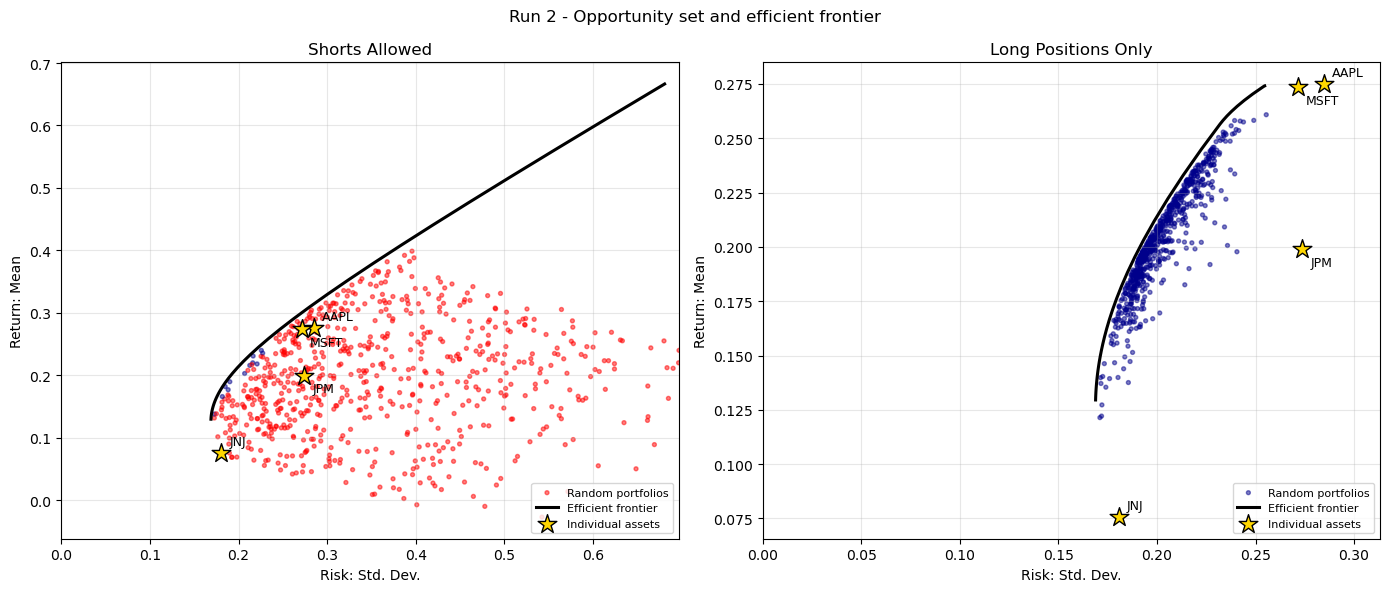

In [40]:

np.random.seed(SEED_RETURNS)
returns_2 = np.random.multivariate_normal(mu_2, cov_2, size=SAMPLE_SIZE)
sample_cov_2 = np.cov(returns_2, rowvar=False) 

np.random.seed(SEED_WEIGHTS)
opp_short_2 = build_opportunity_set(returns_2, sample_cov_2, N_PORTFOLIOS, allow_shorts=True)

np.random.seed(SEED_WEIGHTS)
opp_long_2 = build_opportunity_set(returns_2, sample_cov_2, N_PORTFOLIOS, allow_shorts=False)

frontier_short_2 = compute_efficient_frontier(mu_2, cov_2, allow_shorts=True)
frontier_long_2 = compute_efficient_frontier(mu_2, cov_2, allow_shorts=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sd_max_short = opp_short_2.ret_sd.quantile(0.98)
sd_max_long = max(opp_long_2.ret_sd.max(), sd_2.max()) * 1.10
label_offsets = [(6, 6), (6, -12), (6, 6), (6, -12)]

for ax, opp_df, front_df, label, sd_max in [
    (axes[0], opp_short_2, frontier_short_2, 'Shorts Allowed', sd_max_short),
    (axes[1], opp_long_2, frontier_long_2, 'Long Positions Only', sd_max_long),
]:
    colors = ['red' if x else 'darkblue' for x in opp_df['has_short']]
    ax.scatter(opp_df['ret_sd'], opp_df['ret_mean'], c=colors, s=8, alpha=0.5, label='Random portfolios')
    visible = front_df[front_df['ret_sd'] <= sd_max]
    ax.plot(visible['ret_sd'], visible['ret_mean'], '-', color='black', lw=2.2, label='Efficient frontier')
    ax.scatter(sd_2, mu_2, marker='*', s=200, c='gold', edgecolors='black', zorder=5, label='Individual assets')

    for name, sd_val, mu_val, offset in zip(tickers, sd_2, mu_2, label_offsets):
        ax.annotate(name, (sd_val, mu_val), xytext=offset,
                    textcoords='offset points', fontsize=9)

    ax.set_xlim(0, sd_max)
    ax.set_xlabel('Risk: Std. Dev.')
    ax.set_ylabel('Return: Mean')
    ax.set_title(label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Run 2 - Opportunity set and efficient frontier')
fig.tight_layout()
fig.savefig('figures/run2_real_stocks_opportunity_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

Optimal result for this graph would be a higher return, lower risk -ie the upper left. We see first from the graph on the left that JNJ carries the least risk but also the lowest return, as risk increases with the other securities so does implied return. From the y axis you can see that the overwhelming majority of simulations result in a positive return for this group of stocks. The black line in both represent the optimal result based on return/risk. Each data point is a simulation of splitting money across 4 stocks with the stars representing the actual individual assets. The pattern is similar in the graph on the right, but we can see the more signficant difference in return from JNJ to APPL/MSFT. They are both higher risk (further right on the graph) but have 3 times the return. If you were trying to mitgate risk JNJ would be the choice. The graph also supports the justification for diversifying as a combination of stocks in shown as optimal to any individual stock (see each star is under the optimizer curve). 

In [44]:
cov = np.outer(sd, sd) * correlation
 
np.random.seed(SEED_RETURNS)
returns_data = np.random.multivariate_normal(mu, cov, size=SAMPLE_SIZE)
sample_cov = np.cov(returns_data, rowvar=False)
 
np.random.seed(SEED_WEIGHTS)
shorts_ok = opportunity_set(returns_data, sample_cov, N_PORTFOLIOS, allow_shorts=True)
 
np.random.seed(SEED_WEIGHTS)
long_only = opportunity_set(returns_data, sample_cov, N_PORTFOLIOS, allow_shorts=False)

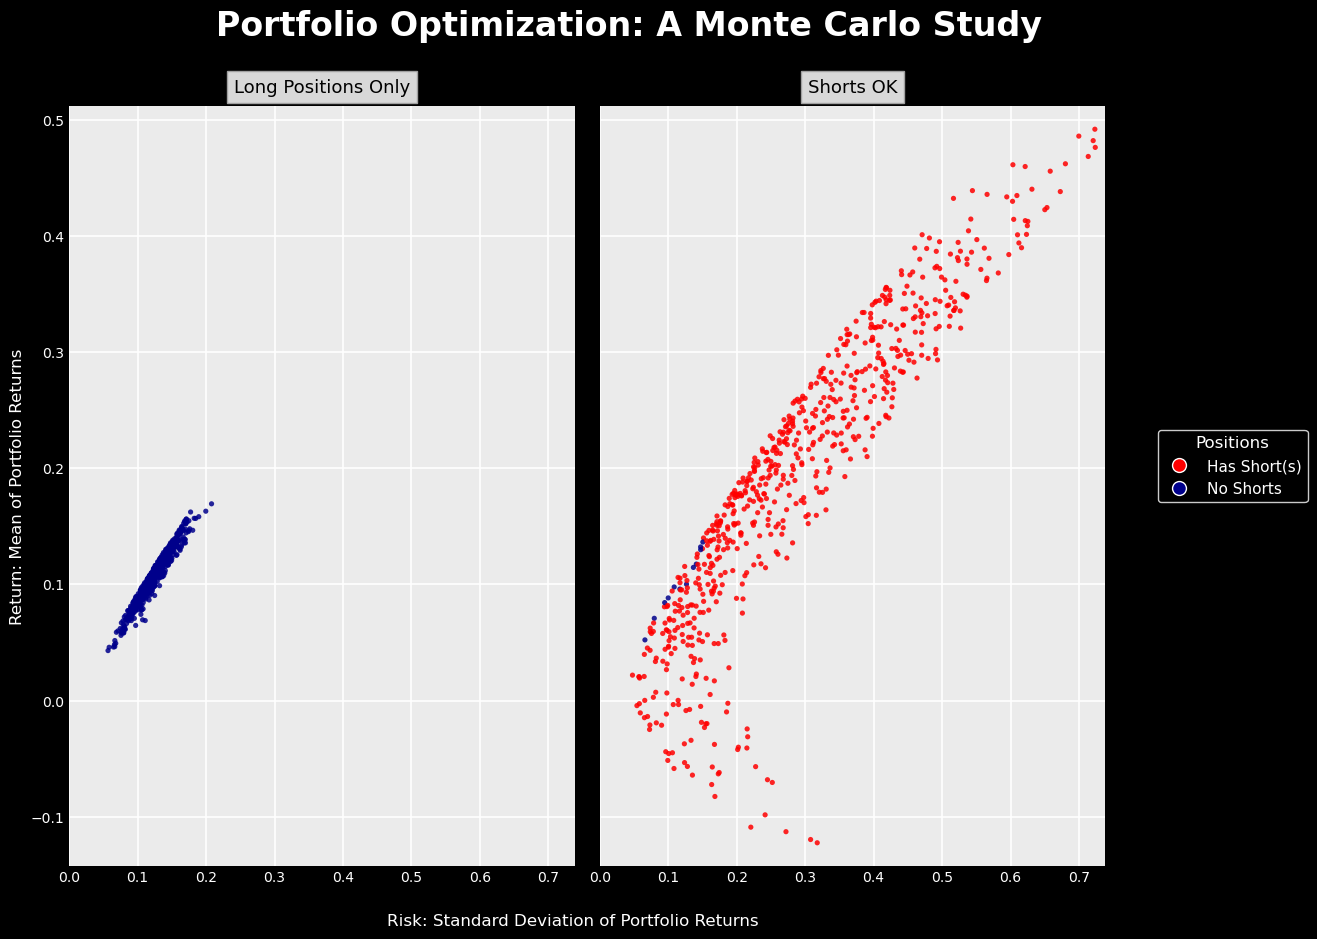

In [45]:

sd_max = max(shorts_ok["ret_sd"].max(), long_only["ret_sd"].max()) * 1.02
ret_min = min(shorts_ok["ret_mean"].min(), long_only["ret_mean"].min()) - 0.02
ret_max = max(shorts_ok["ret_mean"].max(), long_only["ret_mean"].max()) + 0.02

fig = plt.figure(figsize=(14, 10), facecolor="black")
fig.text(0.5, 0.94, TITLE, ha="center", va="center",
         color="white", fontsize=24, fontweight="bold")
gs = fig.add_gridspec(1, 2, left=0.10, right=0.84, top=0.86, bottom=0.10, wspace=0.05)
ax_long = fig.add_subplot(gs[0, 0])
ax_short = fig.add_subplot(gs[0, 1], sharey=ax_long)
 
for ax, df, panel_title in [
    (ax_long, long_only, "Long Positions Only"),
    (ax_short, shorts_ok, "Shorts OK"),
]:
    ax.set_facecolor("#ebebeb")
    colors = ["red" if x else "darkblue" for x in df["has_short"]]
    ax.scatter(df["ret_sd"], df["ret_mean"], c=colors, s=14, alpha=0.85, edgecolors="none")
 
    ax.set_title(panel_title, fontsize=13,
                 bbox=dict(boxstyle="square,pad=0.4",
                           facecolor="#d8d8d8", edgecolor="#a0a0a0"),
                 pad=10)
 
    ax.set_xlim(0, sd_max)
    ax.set_ylim(ret_min, ret_max)
    ax.grid(True, color="white", linewidth=1.2)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors="white", labelcolor="white", labelsize=10, length=0)
 
ax_long.set_ylabel("Return: Mean of Portfolio Returns", fontsize=12, color="white")
ax_short.tick_params(labelleft=False)
fig.text(0.46, 0.04, "Risk: Standard Deviation of Portfolio Returns",
         ha="center", fontsize=12, color="white")
 
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
               markersize=10, label="Has Short(s)", linestyle="None"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="darkblue",
               markersize=10, label="No Shorts", linestyle="None"),
]
legend = fig.legend(handles=legend_handles, loc="center right",
                     bbox_to_anchor=(0.99, 0.5), title="Positions",
                     fontsize=11, title_fontsize=12,
                     facecolor="black", edgecolor="white", labelcolor="white")
legend.get_title().set_color("white")
plt.show()

Following the methodology of Run 1, the 700 scenarios used to build the opportunity set are simulated from a multivariate normal distribution calibrated to AAPL/MSFT/JNJ/JPM's 2015–2024 statistics, rather than being the historical returns themselves. 

In [46]:
# Stochastic program for Run 2
sample_mu_2 = returns_2.mean(axis=0)
saa_short = optimize_portfolio(sample_mu_2, sample_cov_2, lam, allow_shorts=True)
saa_long = optimize_portfolio(sample_mu_2, sample_cov_2, lam, allow_shorts=False)
det_short = optimize_portfolio(mu_2, cov_2, lam, allow_shorts=True)
det_long = optimize_portfolio(mu_2, cov_2, lam, allow_shorts=False)

pd.DataFrame({
    'Ticker': tickers,
    'SAA (shorts)': np.round(saa_short, 4),
    'SAA (long)': np.round(saa_long, 4),
    'Det (shorts)': np.round(det_short, 4),
    'Det (long)': np.round(det_long, 4),
})

,Ticker,SAA (shorts),SAA (long),Det (shorts),Det (long)
0,AAPL,0.3717,0.3717,0.3396,0.3349
1,MSFT,0.4170,0.4170,0.4415,0.4343
2,JNJ,0.0029,0.0029,-0.0216,0.0000
3,JPM,0.2084,0.2084,0.2405,0.2308
